# import 

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import cv2 as cv
from pathlib import Path 
import seaborn as sns
import matplotlib.pyplot as plt
from StatTools.generators.ndfnoise_generator import ndfnoise
from tqdm import tqdm
import plotly.express as px
import os
import warnings 
import gc

In [35]:
from collections import defaultdict
from typing import Optional, Union, Tuple, Dict, Any

import numpy as np
import pandas as pd


def _clip_to_bounds(
    positions: np.ndarray,
    bounds: Optional[Tuple[float, float, float, float]],
) -> np.ndarray:
    """
    Обрезает позиции по границам.

    bounds = (xmin, xmax, ymin, ymax)
    """
    if bounds is None:
        return positions

    xmin, xmax, ymin, ymax = bounds

    positions[:, 0] = np.clip(positions[:, 0], xmin, xmax)
    positions[:, 1] = np.clip(positions[:, 1], ymin, ymax)

    return positions


def _neighbor_pairs(positions: np.ndarray, cell_size: float):
    """
    Возвращает потенциально близкие пары через пространственную сетку.
    """
    grid = defaultdict(list)

    for i, p in enumerate(positions):
        key = (
            int(np.floor(p[0] / cell_size)),
            int(np.floor(p[1] / cell_size)),
        )
        grid[key].append(i)

    neighbor_offsets = (
        (1, 0),
        (0, 1),
        (1, 1),
        (1, -1),
    )

    for (cx, cy), indices in grid.items():
        m = len(indices)

        # Пары внутри одной ячейки.
        for a in range(m):
            i = indices[a]
            for b in range(a + 1, m):
                j = indices[b]
                yield i, j

        # Пары с соседними ячейками.
        for dx, dy in neighbor_offsets:
            other = grid.get((cx + dx, cy + dy))
            if other is None:
                continue

            for i in indices:
                for j in other:
                    yield i, j


def _separate_positions(
    positions: np.ndarray,
    radii: np.ndarray,
    max_iter: int = 8,
    bounds: Optional[Tuple[float, float, float, float]] = None,
    rng: Optional[np.random.Generator] = None,
    relaxation: float = 1.0,
) -> np.ndarray:
    """
    Итеративно разводит позиции объектов так, чтобы расстояние между центрами
    было не меньше r_i + r_j.
    """
    positions = np.asarray(positions, dtype=np.float32)
    pos = positions.copy()

    radii = np.asarray(radii, dtype=np.float32)

    n = pos.shape[0]

    if radii.shape[0] != n:
        raise ValueError("radii должен иметь ту же длину, что и число позиций")

    pos = _clip_to_bounds(pos, bounds)

    if n < 2:
        return pos

    max_iter = max(0, int(max_iter))

    if max_iter <= 0:
        return pos

    max_radius = float(np.max(radii)) if radii.size > 0 else 0.0

    if max_radius <= 0.0:
        return pos

    if rng is None:
        rng = np.random.default_rng()

    cell_size = max(1.0, 2.0 * max_radius)

    for _ in range(max_iter):
        moved = False

        for i, j in _neighbor_pairs(pos, cell_size):
            min_dist = float(radii[i] + radii[j])

            if min_dist <= 0.0:
                continue

            delta = pos[j] - pos[i]
            dist2 = float(delta[0] * delta[0] + delta[1] * delta[1])
            min_dist2 = min_dist * min_dist

            if dist2 < min_dist2:
                moved = True

                dist = float(np.sqrt(dist2))

                if dist < 1e-6:
                    angle = float(rng.random()) * 2.0 * np.pi
                    direction = np.array(
                        [np.cos(angle), np.sin(angle)],
                        dtype=np.float32,
                    )
                else:
                    direction = delta / dist

                overlap = min_dist - dist
                correction = 0.5 * relaxation * overlap * direction

                pos[i] -= correction
                pos[j] += correction

        pos = _clip_to_bounds(pos, bounds)

        if not moved:
            break

    return pos


def _is_scalar_radius(value: Any) -> bool:
    return np.isscalar(value) or (isinstance(value, np.ndarray) and value.ndim == 0)


def _get_frame_radii(
    g: pd.DataFrame,
    radii: Union[float, str, Dict[Any, float], pd.Series, callable],
    track_col: str,
) -> np.ndarray:
    """
    Возвращает массив радиусов для объектов в одном кадре.
    """
    n = len(g)

    if _is_scalar_radius(radii):
        return np.full(n, float(radii), dtype=np.float32)

    if isinstance(radii, str):
        return g[radii].astype(np.float32).to_numpy()

    if isinstance(radii, (dict, pd.Series)):
        mapped = g[track_col].map(radii)

        if mapped.isna().any():
            missing = g.loc[mapped.isna(), track_col].unique()
            raise ValueError(
                f"Не для всех track заданы радиусы. Примеры: {missing[:10]}"
            )

        return mapped.astype(np.float32).to_numpy()

    if callable(radii):
        values = radii(g)
        arr = np.asarray(values, dtype=np.float32)

        if arr.ndim == 0:
            return np.full(n, float(arr), dtype=np.float32)

        if arr.size == n:
            return arr.reshape(-1)

        raise ValueError(
            "Если radii является callable, функция должна возвращать скаляр "
            "или массив длиной равной числу строк в кадре."
        )

    raise ValueError(
        "radii должен быть скаляром, именем столбца, dict, pd.Series или callable."
    )


def postprocess_collisions_long(
    df: pd.DataFrame,
    track_col: str = "track_id",
    frame_col: str = "frame",
    x_col: str = "x",
    y_col: str = "y",
    radii: Union[float, str, Dict[Any, float], pd.Series, callable] = 1.0,
    bounds: Optional[Tuple[float, float, float, float]] = None,
    max_iter: int = 8,
    substeps: int = 1,
    relaxation: float = 1.0,
    max_frame_gap: Optional[Union[int, float]] = None,
    seed: Optional[int] = None,
    return_float: bool = False,
    keep_raw: bool = False,
    inplace: bool = False,
) -> pd.DataFrame:
    """
    Постобработка траекторий в long-формате для устранения столкновений.

    Параметры
    ---------
    df : pd.DataFrame
        Таблица вида одна строка = один объект в одном кадре.

    track_col : str
        Имя столбца с идентификатором трека.

    frame_col : str
        Имя столбца с номером кадра. Должен быть числовым.

    x_col, y_col : str
        Имена столбцов с координатами.

    radii : float, str, dict, pd.Series или callable
        Эффективный радиус объекта.

        Варианты:
        - скаляр: один радиус для всех треков;
        - имя столбца: радиус берется из столбца;
        - dict / pd.Series: mapping track_id -> radius;
        - callable: функция от группы кадра, возвращает скаляр или массив.

    bounds : tuple или None
        Границы области: (xmin, xmax, ymin, ymax).
        Если None, границы не учитываются.

    max_iter : int
        Число итераций разрешения пересечений.

    substeps : int
        Число подшагов между соседними наблюдаемыми кадрами.
        Полезно при больших перемещениях.

    relaxation : float
        Коэффициент релаксации. Обычно 1.0.

    max_frame_gap : int, float или None
        Максимальный допустимый разрыв кадров для продолжения трека.

        Если None, трек продолжается от последнего наблюдаемого кадра,
        даже если были пропуски.

        Если задать 1, продолжение будет только для соседних кадров:
        frame_prev + 1 == frame_current.

    seed : int или None
        Seed для воспроизводимости.

    return_float : bool
        Если True, возвращает float-координаты.
        Если False, округляет до int32.

    keep_raw : bool
        Если True, сохраняет исходные координаты в столбцах:
        {x_col}_raw, {y_col}_raw.

    inplace : bool
        Если False, делает копию df.
        Если True, модифицирует исходный df.
    """
    required_cols = [track_col, frame_col, x_col, y_col]
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(f"В DataFrame отсутствуют обязательные столбцы: {missing_cols}")

    # Базовые проверки.
    if df[[track_col, frame_col, x_col, y_col]].isna().any().any():
        raise ValueError("В столбцах track/frame/x/y присутствуют пропуски.")

    if df.duplicated(subset=[frame_col, track_col]).any():
        raise ValueError("Обнаружены дубликаты: один и тот же трек в одном кадре.")

    # Проверка radii.
    if _is_scalar_radius(radii):
        pass

    elif isinstance(radii, str):
        if radii not in df.columns:
            raise ValueError(f"Столбец с радиусами '{radii}' не найден.")

        if df[radii].isna().any():
            raise ValueError("В столбце радиусов есть пропуски.")

    elif isinstance(radii, (dict, pd.Series)):
        keys = set(radii.keys())
        missing_tracks = df.loc[~df[track_col].isin(keys), track_col].unique()

        if len(missing_tracks) > 0:
            raise ValueError(
                f"Для части треков не задан радиус. Примеры: {missing_tracks[:10]}"
            )

    elif callable(radii):
        pass

    else:
        raise ValueError(
            "radii должен быть скаляром, именем столбца, dict, pd.Series или callable."
        )

    if max_frame_gap is not None and max_frame_gap < 0:
        raise ValueError("max_frame_gap должен быть неотрицательным или None.")

    out = df if inplace else df.copy()

    # Служебный столбец для восстановления исходного порядка.
    temp_order = "__orig_order__"
    while temp_order in out.columns:
        temp_order += "_"

    out[temp_order] = np.arange(len(out))

    if keep_raw:
        out[f"{x_col}_raw"] = out[x_col]
        out[f"{y_col}_raw"] = out[y_col]

    # Сортируем по кадру и треку.
    out.sort_values(
        by=[frame_col, track_col],
        kind="mergesort",
        inplace=True,
    )
    out.reset_index(drop=True, inplace=True)

    corr_x = np.empty(len(out), dtype=np.float32)
    corr_y = np.empty(len(out), dtype=np.float32)

    rng = np.random.default_rng(seed)

    state_pos: Dict[Any, np.ndarray] = {}
    state_raw_frame: Dict[Any, Union[int, float]] = {}
    state_raw_pos: Dict[Any, np.ndarray] = {}

    max_iter = max(0, int(max_iter))
    substeps = max(1, int(substeps))

    # Обработка по кадрам.
    for frame, g in out.groupby(frame_col, sort=True):
        pos_idx = g.index.to_numpy()

        track_ids = g[track_col].to_numpy()
        raw_pos = g[[x_col, y_col]].to_numpy(dtype=np.float32)

        n = len(g)

        radii_arr = _get_frame_radii(g, radii, track_col)

        final_pos = np.empty((n, 2), dtype=np.float32)
        moving_mask = np.zeros(n, dtype=bool)

        # Определяем, какие треки можно продолжить из предыдущего состояния.
        for k, tid in enumerate(track_ids):
            last_frame = state_raw_frame.get(tid, None)

            can_continue = False

            if (
                last_frame is not None
                and tid in state_pos
                and tid in state_raw_pos
            ):
                gap = frame - last_frame

                if gap > 0:
                    if max_frame_gap is None or gap <= max_frame_gap:
                        can_continue = True

            if can_continue:
                moving_mask[k] = True
            else:
                # Новый трек или трек с большим разрывом:
                # используем исходную позицию как предложенную.
                final_pos[k] = raw_pos[k]

        # Двигаем треки, которые пришли из предыдущих состояний.
        if moving_mask.any():
            moving_idx = np.nonzero(moving_mask)[0]
            moving_tracks = track_ids[moving_idx]

            start_pos = np.vstack(
                [state_pos[tid] for tid in moving_tracks]
            ).astype(np.float32)

            last_raw_pos = np.vstack(
                [state_raw_pos[tid] for tid in moving_tracks]
            ).astype(np.float32)

            desired_delta = raw_pos[moving_idx] - last_raw_pos
            step_delta = desired_delta / float(substeps)

            moving_radii = radii_arr[moving_idx]

            pos = start_pos

            for _ in range(substeps):
                pos = pos + step_delta
                pos = _separate_positions(
                    pos,
                    radii=moving_radii,
                    max_iter=max_iter,
                    bounds=bounds,
                    rng=rng,
                    relaxation=relaxation,
                )

            final_pos[moving_idx] = pos

        # Финальная сепарация всех активных объектов в кадре.
        # Если все треки пришли из предыдущего кадра, они уже были обработаны
        # на подшагах, но если есть новые треки, нужна общая сепарация.
        if n > 0 and not moving_mask.all():
            final_pos = _separate_positions(
                final_pos,
                radii=radii_arr,
                max_iter=max_iter,
                bounds=bounds,
                rng=rng,
                relaxation=relaxation,
            )

        corr_x[pos_idx] = final_pos[:, 0]
        corr_y[pos_idx] = final_pos[:, 1]

        # Обновляем состояния треков.
        for k, tid in enumerate(track_ids):
            state_pos[tid] = final_pos[k].copy()
            state_raw_frame[tid] = frame
            state_raw_pos[tid] = raw_pos[k].copy()

    # Записываем результат.
    out[x_col] = corr_x
    out[y_col] = corr_y

    if return_float:
        out[x_col] = out[x_col].astype(np.float32)
        out[y_col] = out[y_col].astype(np.float32)
    else:
        out[x_col] = np.round(out[x_col]).astype(np.int32)
        out[y_col] = np.round(out[y_col]).astype(np.int32)

    # Восстанавливаем исходный порядок строк.
    out.sort_values(temp_order, inplace=True)
    out.drop(columns=temp_order, inplace=True)
    out.reset_index(drop=True, inplace=True)

    return out

# make species tracks long df

In [2]:
dir_path = Path(fr'../data/knn_kalman/pyeensis')
files = list(dir_path.glob("*.csv"))
pbar = tqdm(files)
result = []
for file_path in pbar:
    df = pd.read_csv(file_path, dtype={'frame':np.uint16, 'track_id':np.uint16, 'x':np.float16, 'y':np.float16}, usecols=['frame', 'track_id', 'x', 'y'])
    df = df[(df['x']>=0)&(df['y']>=0)].reset_index(drop=True)
    df = df.round().astype({'x': np.uint16, 'y': np.uint16})
    df['file_path'] = file_path.name
    result.append(df)
df_pyeensis = pd.concat(result)
overall_pyeensis_lens = df_pyeensis.groupby(['file_path', 'track_id'])['frame'].count()

100%|██████████| 45/45 [00:05<00:00,  7.95it/s]


In [3]:
dir_path = Path(fr'../data/knn_kalman/frufa')
files = list(dir_path.glob("*.csv"))
pbar = tqdm(files)
result = []
for file_path in pbar:
    df = pd.read_csv(file_path, dtype={'frame':np.uint16, 'track_id':np.uint16, 'x':np.float16, 'y':np.float16}, usecols=['frame', 'track_id', 'x', 'y'])
    df = df[(df['x']>=0)&(df['y']>=0)].reset_index(drop=True)
    df = df.round().astype({'x': np.uint16, 'y': np.uint16})
    df['file_path'] = file_path.name
    result.append(df)
df_frufa = pd.concat(result)
overall_frufa_lens = df_frufa.groupby(['file_path', 'track_id'])['frame'].count()

100%|██████████| 21/21 [00:03<00:00,  5.68it/s]


# make synth species tracks

In [58]:
result = []
frame_shape = (720, 1280)

pbar = tqdm(list(df_pyeensis.groupby("file_path"))[::-1])

for file_path, file_df in pbar:
    pbar.set_description(f"Processing {file_path}")

    lens = file_df.groupby("track_id")["frame"].count()
    indices = lens.cumsum()

    pow = np.ceil(np.log2(lens.sum())).astype(int)

    fgn = ndfnoise(
        shape=(2 ** pow, 2),
        hurst=(0.94, 0.5),
        dtype=np.float32,
    )

    chunks = np.split(fgn, indices)[:-1]

    idx = np.repeat(lens.index.to_list(), lens)

    synth_df = file_df.sort_values(["track_id", "frame"]).copy()

    synth_df[["x", "y"]] = np.concat(chunks, axis=0)
    synth_df[["x", "y"]] = (
        synth_df.groupby("track_id")[["x", "y"]]
        .cumsum()
        .round()
        .astype(np.int32)
    )

    start_x = np.random.randint(0, frame_shape[1], (len(lens),)).repeat(lens)
    start_y = np.random.randint(0, frame_shape[0], (len(lens),)).repeat(lens)

    start_point = np.stack([start_x, start_y], axis=1)

    synth_df[["x", "y"]] += start_point

    # Постобработка коллизий.
    synth_df = postprocess_collisions_long(
        synth_df,
        track_col="track_id",
        frame_col="frame",
        x_col="x",
        y_col="y",
        radii=5,
        bounds=(0, frame_shape[1], 0, frame_shape[0]),              # или задать границы
        max_iter=8,
        substeps=1,
        relaxation=1.0,
        max_frame_gap=None,       # None: продолжать даже при пропусках кадров
        seed=42,
        return_float=False,
        keep_raw=False,
        inplace=False,
    )
    break
    # synth_df.to_csv(f"../data/synth_species/pyeensis/{file_path}", index=False)

Processing S2190017.csv:   0%|          | 0/45 [00:00<?, ?it/s]/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in power
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))
Processing S2190017.csv:   0%|          | 0/45 [00:02<?, ?it/s]


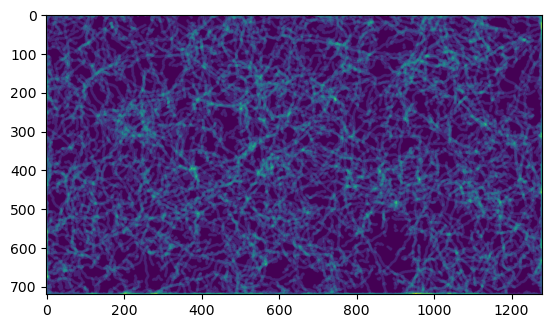

In [59]:
canvas = np.zeros(frame_shape, dtype=np.uint16)
for tr in synth_df['track_id'].unique():
    pts = synth_df.loc[(synth_df['track_id']==tr), ['x', 'y']].to_numpy(dtype=np.int32)
    # calc track l2 length
    # increments = np.diff(pts, axis=0)
    # l2_len += np.linalg.norm(increments, axis=1).sum()

    # draw track
    buffer = np.zeros(frame_shape, dtype=np.uint8)
    cv.polylines(
        buffer,
        [pts],
        isClosed=False,
        color=1,
        thickness=5
    )
    canvas+=buffer

plt.imshow(canvas, cmap='viridis')

## frufa

In [60]:
result = []
frame_shape = (480, 848)

pbar = tqdm(list(df_frufa.groupby('file_path')))
for file_path, file_df in pbar:
    pbar.set_description(f"Processing {file_path}")
    # get track lens
    lens = file_df.groupby('track_id')['frame'].count()
    # for each track get bound indices
    indices = lens.cumsum()
    # specify general fgn len
    pow = np.ceil(np.log2(lens.sum())).astype(int)
    # make fgn
    fgn = ndfnoise(shape = (2**pow,2), hurst=(0.94, 0.5), dtype=np.float32)
    # chop general fgn into chunks, last one is invalid tail
    chunks = np.split(fgn, indices)[:-1]
    # explode lond trackid
    idx = np.repeat(lens.index.to_list(), lens)
    #collect total df with original shell
    synth_df = file_df.sort_values(['track_id', 'frame'])
    synth_df[['x', 'y']] = np.concat(chunks, axis=0)
    synth_df[['x', 'y']] = synth_df.groupby('track_id')[['x', 'y']].cumsum().round().astype(np.int32)
    # define random start points
    start_x = np.random.randint(0, frame_shape[1], (len(lens),)).repeat(lens)
    start_y = np.random.randint(0, frame_shape[0], (len(lens),)).repeat(lens)
    start_point = np.stack([start_x, start_y], axis=1)
    synth_df[['x', 'y']] += start_point

    synth_df = postprocess_collisions_long(
        synth_df,
        track_col="track_id",
        frame_col="frame",
        x_col="x",
        y_col="y",
        radii=5,
        bounds=None,
        max_iter=8,
        substeps=1,
        relaxation=1.0,
        max_frame_gap=None,
        seed=42,
        return_float=False,
        keep_raw=False,
        inplace=False,
    )
    synth_df.to_csv(f'../data/synth_species_collision/frufa/{file_path}')

Processing S1240004начало.csv:   0%|          | 0/21 [00:00<?, ?it/s]/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in power
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))
Processing S1240005.csv:   5%|▍         | 1/21 [00:03<01:18,  3.92s/it]      /home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in power
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))
Processing S1240006.csv:  10%|▉         | 2/21 [00:04<00:37,  2.00s/it]/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in power
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))
Processing S1240007.csv:  14%|█▍        | 3/21 [00:13<01:32,  5.16s/it]/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_genera

## pyeensis

In [61]:
result = []
frame_shape = (720, 1280)
pbar = tqdm(list(df_pyeensis.groupby('file_path')))
for file_path, file_df in pbar:
    pbar.set_description(f"Processing {file_path}")
    # get track lens
    lens = file_df.groupby('track_id')['frame'].count()
    # for each track get bound indices
    indices = lens.cumsum()
    # specify general fgn len
    pow = np.ceil(np.log2(lens.sum())).astype(int)
    # make fgn
    fgn = ndfnoise(shape = (2**pow,2), hurst=(0.94, 0.5), dtype=np.float32)
    # chop general fgn into chunks, last one is invalid tail
    chunks = np.split(fgn, indices)[:-1]
    # explode lond trackid
    idx = np.repeat(lens.index.to_list(), lens)
    #collect total df with original shell
    synth_df = file_df.sort_values(['track_id', 'frame'])
    synth_df[['x', 'y']] = np.concat(chunks, axis=0)
    synth_df[['x', 'y']] = synth_df.groupby('track_id')[['x', 'y']].cumsum().round().astype(np.int32)
    # define random start points
    start_x = np.random.randint(0, frame_shape[1], (len(lens),)).repeat(lens)
    start_y = np.random.randint(0, frame_shape[0], (len(lens),)).repeat(lens)
    start_point = np.stack([start_x, start_y], axis=1)
    synth_df[['x', 'y']] += start_point
    synth_df = postprocess_collisions_long(
        synth_df,
        track_col="track_id",
        frame_col="frame",
        x_col="x",
        y_col="y",
        radii=2,
        bounds=(0, frame_shape[1], 0, frame_shape[0]),
        max_iter=8,
        substeps=1,
        relaxation=1.0,
        max_frame_gap=None,
        seed=42,
        return_float=False,
        keep_raw=False,
        inplace=False,
    )
    synth_df.to_csv(f'../data/synth_species_collision/pyeensis/{file_path}')


Processing S2170005.csv:   0%|          | 0/45 [00:00<?, ?it/s]/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in power
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))
Processing S2170006.csv:   2%|▏         | 1/45 [00:00<00:07,  6.13it/s]/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in power
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))
Processing S2170007.csv:   4%|▍         | 2/45 [00:00<00:12,  3.50it/s]/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in power
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))
Processing S2170008.csv:   7%|▋         | 3/45 [00:03<00:56,  1.34s/it]/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: R